### Experiment 3 - Regression Analysis using Linear and Regularized Models

Name: Priya Verma  | Class: CSE B | Reg. No: 3122235001102

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import RobustScaler
import time 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from matplotlib import cm 
from mpl_toolkits.mplot3d import Axes3D


plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 15,
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})


### 1. Load the dataset

In [ ]:
# loading dataset
df_train = pd.read_csv("datasets/train.csv")
df_test = pd.read_csv("datasets/test.csv")

In [3]:
df_train.head()

,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28


In [4]:
df_test.head()

,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Dependents,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price
0,C-26247,Tandra Olszewski,F,47,3472.69,Low,Commercial associate,Managers,Semi-Urban,137088.98,...,2.0,799.14,0,Unpossessed,843,3472.69,2,Urban,1,236644.5
1,C-35067,Jeannette Cha,F,57,1184.84,Low,Working,Sales staff,Rural,104771.59,...,2.0,833.31,0,Unpossessed,22,1184.84,1,Rural,1,142357.3
2,C-34590,Keva Godfrey,F,52,1266.27,Low,Working,NaN,Semi-Urban,176684.91,...,3.0,627.44,0,Unpossessed,1,1266.27,1,Urban,1,300991.24
3,C-16668,Elva Sackett,M,65,1369.72,High,Pensioner,NaN,Rural,97009.18,...,2.0,833.20,0,Inactive,730,1369.72,1,Semi-Urban,0,125612.1
4,C-12196,Sade Constable,F,60,1939.23,High,Pensioner,NaN,Urban,109980.00,...,NaN,NaN,0,NaN,356,1939.23,4,Semi-Urban,1,180908.0


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  object 
 1   Name                         30000 non-null  object 
 2   Gender                       29947 non-null  object 
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stability             28317 non-null  object 
 6   Profession                   30000 non-null  object 
 7   Type of Employment           22730 non-null  object 
 8   Location                     30000 non-null  object 
 9   Loan Amount Request (USD)    30000 non-null  float64
 10  Current Loan Expenses (USD)  29828 non-null  float64
 11  Expense Type 1               30000 non-null  object 
 12  Expense Type 2               30000 non-null  object 
 13  Dependents      

In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  20000 non-null  object 
 1   Name                         20000 non-null  object 
 2   Gender                       19969 non-null  object 
 3   Age                          20000 non-null  int64  
 4   Income (USD)                 19250 non-null  float64
 5   Income Stability             19187 non-null  object 
 6   Profession                   20000 non-null  object 
 7   Type of Employment           15311 non-null  object 
 8   Location                     20000 non-null  object 
 9   Loan Amount Request (USD)    20000 non-null  float64
 10  Current Loan Expenses (USD)  19917 non-null  float64
 11  Expense Type 1               20000 non-null  object 
 12  Expense Type 2               20000 non-null  object 
 13  Dependents      

In [7]:
df_train.columns

Index(['Customer ID', 'Name', 'Gender', 'Age', 'Income (USD)',
       'Income Stability', 'Profession', 'Type of Employment', 'Location',
       'Loan Amount Request (USD)', 'Current Loan Expenses (USD)',
       'Expense Type 1', 'Expense Type 2', 'Dependents', 'Credit Score',
       'No. of Defaults', 'Has Active Credit Card', 'Property ID',
       'Property Age', 'Property Type', 'Property Location', 'Co-Applicant',
       'Property Price', 'Loan Sanction Amount (USD)'],
      dtype='object')

### 2. Perform data preprocessing:

In [8]:
## Checking if any duplicate rows are found.
print("Duplicates in train data: ", any(df_train.duplicated()))
print("Duplicates in test data: ", any(df_test.duplicated()))

Duplicates in train data:  False
Duplicates in test data:  False


In [9]:
## Remove unnecessary columns such as Customer ID, Name
cols_to_drop = ['Customer ID', 'Name']

df_train.drop(columns=cols_to_drop, inplace=True)
df_test.drop(columns=cols_to_drop, inplace=True)

In [10]:
# Remove rows with negative Loan Amount
df_train = df_train[df_train["Loan Sanction Amount (USD)"] > 0]

In [11]:
## Checking the unique values of columns
print(df_test['Co-Applicant'].unique())


['1' '0' '?']


In [12]:
### Since the data types of the Co-Applicant and Property price in train and test data is different, so making it same
df_test['Co-Applicant'] = df_test['Co-Applicant'].replace('?', np.nan)
df_test['Co-Applicant'] = df_test['Co-Applicant'].fillna(df_test['Co-Applicant'].mode()[0]).astype(float)

df_test['Property Price'] = df_test['Property Price'].replace('?', np.nan)

df_test['Co-Applicant'] = df_test['Co-Applicant'].astype(float)
df_test['Property Price'] = df_test['Property Price'].astype(float)
df_test['Property Price'] = df_test['Property Price'].fillna(df_test['Property Price'].mean()).astype(float)


In [13]:
# Checking the missing and null values...for train data
df_train.isnull().sum()

Gender                           37
Age                               0
Income (USD)                   3868
Income Stability               1442
Profession                        0
Type of Employment             5596
Location                          0
Loan Amount Request (USD)         0
Current Loan Expenses (USD)     145
Expense Type 1                    0
Expense Type 2                    0
Dependents                     2075
Credit Score                   1430
No. of Defaults                   0
Has Active Credit Card         1121
Property ID                       0
Property Age                   4099
Property Type                     0
Property Location               303
Co-Applicant                      0
Property Price                    0
Loan Sanction Amount (USD)        0
dtype: int64

In [14]:
# Checking the missing and null values...for test data
df_test.isnull().sum()

Gender                           31
Age                               0
Income (USD)                    750
Income Stability                813
Profession                        0
Type of Employment             4689
Location                          0
Loan Amount Request (USD)         0
Current Loan Expenses (USD)      83
Expense Type 1                    0
Expense Type 2                    0
Dependents                     1142
Credit Score                    743
No. of Defaults                   0
Has Active Credit Card         1076
Property ID                       0
Property Age                    892
Property Type                     0
Property Location               160
Co-Applicant                      0
Property Price                    0
dtype: int64

In [15]:
## Handle Missing Values
## dropping rows which has target feature missing
df_train = df_train.dropna(subset=['Loan Sanction Amount (USD)'])

In [16]:
df_train.isnull().sum()

Gender                           37
Age                               0
Income (USD)                   3868
Income Stability               1442
Profession                        0
Type of Employment             5596
Location                          0
Loan Amount Request (USD)         0
Current Loan Expenses (USD)     145
Expense Type 1                    0
Expense Type 2                    0
Dependents                     2075
Credit Score                   1430
No. of Defaults                   0
Has Active Credit Card         1121
Property ID                       0
Property Age                   4099
Property Type                     0
Property Location               303
Co-Applicant                      0
Property Price                    0
Loan Sanction Amount (USD)        0
dtype: int64

In [ ]:
df_train.shape 

(21457, 22)

In [18]:
## Handle Missing Values

## Numerical Features → Mean
num_train_cols = df_train.select_dtypes(include=["int64","float64"]).columns
num_imputer = SimpleImputer(strategy="median")

df_train[num_train_cols] = num_imputer.fit_transform(df_train[num_train_cols])

num_test_cols = df_test.select_dtypes(include=["int64","float64"]).columns
num_imputer = SimpleImputer(strategy="median")

df_test[num_test_cols] = num_imputer.fit_transform(df_test[num_test_cols])

In [19]:
## Handle Missing Values

## Categorical Features → Mode
cat_cols = df_train.select_dtypes(include=["object"]).columns
cat_imputer = SimpleImputer(strategy="most_frequent")

df_train[cat_cols] = cat_imputer.fit_transform(df_train[cat_cols])
df_test[cat_cols] = cat_imputer.transform(df_test[cat_cols])


In [20]:
# After handling missing values...for train data
df_train.isnull().sum()

Gender                         0
Age                            0
Income (USD)                   0
Income Stability               0
Profession                     0
Type of Employment             0
Location                       0
Loan Amount Request (USD)      0
Current Loan Expenses (USD)    0
Expense Type 1                 0
Expense Type 2                 0
Dependents                     0
Credit Score                   0
No. of Defaults                0
Has Active Credit Card         0
Property ID                    0
Property Age                   0
Property Type                  0
Property Location              0
Co-Applicant                   0
Property Price                 0
Loan Sanction Amount (USD)     0
dtype: int64

In [21]:
## After handling missing values ... for test data
df_test.isnull().sum()

Gender                         0
Age                            0
Income (USD)                   0
Income Stability               0
Profession                     0
Type of Employment             0
Location                       0
Loan Amount Request (USD)      0
Current Loan Expenses (USD)    0
Expense Type 1                 0
Expense Type 2                 0
Dependents                     0
Credit Score                   0
No. of Defaults                0
Has Active Credit Card         0
Property ID                    0
Property Age                   0
Property Type                  0
Property Location              0
Co-Applicant                   0
Property Price                 0
dtype: int64

In [22]:
df_train.columns

Index(['Gender', 'Age', 'Income (USD)', 'Income Stability', 'Profession',
       'Type of Employment', 'Location', 'Loan Amount Request (USD)',
       'Current Loan Expenses (USD)', 'Expense Type 1', 'Expense Type 2',
       'Dependents', 'Credit Score', 'No. of Defaults',
       'Has Active Credit Card', 'Property ID', 'Property Age',
       'Property Type', 'Property Location', 'Co-Applicant', 'Property Price',
       'Loan Sanction Amount (USD)'],
      dtype='object')

In [23]:
df_test.columns

Index(['Gender', 'Age', 'Income (USD)', 'Income Stability', 'Profession',
       'Type of Employment', 'Location', 'Loan Amount Request (USD)',
       'Current Loan Expenses (USD)', 'Expense Type 1', 'Expense Type 2',
       'Dependents', 'Credit Score', 'No. of Defaults',
       'Has Active Credit Card', 'Property ID', 'Property Age',
       'Property Type', 'Property Location', 'Co-Applicant', 'Property Price'],
      dtype='object')

In [24]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21457 entries, 0 to 29999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       21457 non-null  object 
 1   Age                          21457 non-null  float64
 2   Income (USD)                 21457 non-null  float64
 3   Income Stability             21457 non-null  object 
 4   Profession                   21457 non-null  object 
 5   Type of Employment           21457 non-null  object 
 6   Location                     21457 non-null  object 
 7   Loan Amount Request (USD)    21457 non-null  float64
 8   Current Loan Expenses (USD)  21457 non-null  float64
 9   Expense Type 1               21457 non-null  object 
 10  Expense Type 2               21457 non-null  object 
 11  Dependents                   21457 non-null  float64
 12  Credit Score                 21457 non-null  float64
 13  No. of Defaults      

In [25]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       20000 non-null  object 
 1   Age                          20000 non-null  float64
 2   Income (USD)                 20000 non-null  float64
 3   Income Stability             20000 non-null  object 
 4   Profession                   20000 non-null  object 
 5   Type of Employment           20000 non-null  object 
 6   Location                     20000 non-null  object 
 7   Loan Amount Request (USD)    20000 non-null  float64
 8   Current Loan Expenses (USD)  20000 non-null  float64
 9   Expense Type 1               20000 non-null  object 
 10  Expense Type 2               20000 non-null  object 
 11  Dependents                   20000 non-null  float64
 12  Credit Score                 20000 non-null  float64
 13  No. of Defaults 

In [26]:
### Encoding Categorical Variables
le = LabelEncoder()

for col in df_train.select_dtypes(include='object'):
    all_values = pd.concat([df_train[col], df_test[col]])
    le.fit(all_values)
    df_train[col] = le.transform(df_train[col])
    df_test[col] = le.transform(df_test[col])


In [27]:
## After encoding categorical variables, the data types of all columns of train data
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21457 entries, 0 to 29999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       21457 non-null  int64  
 1   Age                          21457 non-null  float64
 2   Income (USD)                 21457 non-null  float64
 3   Income Stability             21457 non-null  int64  
 4   Profession                   21457 non-null  int64  
 5   Type of Employment           21457 non-null  int64  
 6   Location                     21457 non-null  int64  
 7   Loan Amount Request (USD)    21457 non-null  float64
 8   Current Loan Expenses (USD)  21457 non-null  float64
 9   Expense Type 1               21457 non-null  int64  
 10  Expense Type 2               21457 non-null  int64  
 11  Dependents                   21457 non-null  float64
 12  Credit Score                 21457 non-null  float64
 13  No. of Defaults      

In [28]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       20000 non-null  int64  
 1   Age                          20000 non-null  float64
 2   Income (USD)                 20000 non-null  float64
 3   Income Stability             20000 non-null  int64  
 4   Profession                   20000 non-null  int64  
 5   Type of Employment           20000 non-null  int64  
 6   Location                     20000 non-null  int64  
 7   Loan Amount Request (USD)    20000 non-null  float64
 8   Current Loan Expenses (USD)  20000 non-null  float64
 9   Expense Type 1               20000 non-null  int64  
 10  Expense Type 2               20000 non-null  int64  
 11  Dependents                   20000 non-null  float64
 12  Credit Score                 20000 non-null  float64
 13  No. of Defaults 

In [29]:
df_train.head()

,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Expense Type 1,...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,0,56.0,1933.05,1,7,14,1,72809.58,241.08,0,...,809.44,0.0,0,746.0,1933.050,4.0,0,1.0,119933.46,54607.18
1,1,32.0,4952.91,1,7,8,1,46837.47,495.81,0,...,780.40,0.0,2,608.0,4952.910,2.0,0,1.0,54791.00,37469.98
2,0,65.0,988.19,0,3,8,1,45593.04,171.95,0,...,833.15,0.0,2,546.0,988.190,2.0,2,0.0,72440.58,36474.43
3,0,65.0,2251.36,0,3,8,0,80057.92,298.54,0,...,832.70,1.0,2,890.0,2252.305,2.0,1,1.0,121441.51,56040.54
4,0,31.0,2614.77,1,7,6,1,113858.89,491.41,0,...,745.55,1.0,0,715.0,2614.770,4.0,1,1.0,208567.91,74008.28


In [30]:
## Separate features (X) and target (y)
X = df_train.drop("Loan Sanction Amount (USD)", axis=1)
y = df_train["Loan Sanction Amount (USD)"]

### 3. Perform Exploratory Data Analysis (EDA)

In [31]:
## Statistical summary for train data

df_train.describe()

,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Expense Type 1,...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
count,21457.000000,21457.000000,2.145700e+04,21457.000000,21457.000000,21457.000000,21457.000000,21457.000000,21457.000000,21457.000000,...,21457.000000,21457.000000,21457.000000,21457.000000,2.145700e+04,21457.000000,21457.000000,21457.000000,2.145700e+04,21457.000000
mean,0.502866,40.389430,2.613918e+03,0.899753,4.711516,7.875985,0.940159,91495.926906,405.938146,0.354803,...,757.956227,0.193690,0.932749,500.597288,2.610179e+03,2.458825,0.971990,-5.247891,1.355782e+05,65881.397768
std,0.500003,16.212181,1.222481e+04,0.300336,2.626624,3.892507,0.525947,60796.889284,249.570239,0.478465,...,60.604919,0.395198,0.824392,287.570170,1.222371e+04,1.119531,0.800359,78.484035,9.573963e+04,44858.650085
min,0.000000,18.000000,3.787600e+02,0.000000,0.000000,0.000000,0.000000,6108.050000,-999.000000,0.000000,...,620.080000,0.000000,0.000000,1.000000,3.787600e+02,1.000000,0.000000,-999.000000,-9.990000e+02,4023.180000
25%,0.000000,25.000000,1.769020e+03,1.000000,1.000000,6.000000,1.000000,42053.750000,251.630000,0.000000,...,708.550000,0.000000,0.000000,250.000000,1.787940e+03,1.000000,0.000000,1.000000,6.245823e+04,30310.860000
50%,1.000000,40.000000,2.251360e+03,1.000000,7.000000,8.000000,1.000000,77334.440000,380.450000,0.000000,...,756.420000,0.000000,1.000000,500.000000,2.252305e+03,2.000000,1.000000,1.000000,1.133293e+05,55191.660000
75%,1.000000,56.000000,2.869780e+03,1.000000,7.000000,10.000000,1.000000,123930.540000,527.810000,1.000000,...,805.920000,0.000000,2.000000,749.000000,2.849640e+03,3.000000,2.000000,1.000000,1.852552e+05,89126.820000
max,1.000000,65.000000,1.777460e+06,1.000000,7.000000,17.000000,2.000000,602384.150000,3840.880000,1.000000,...,896.260000,1.000000,2.000000,999.000000,1.777460e+06,4.000000,2.000000,1.000000,1.028083e+06,481907.320000


In [32]:
df_test.describe()

,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Expense Type 1,...,Dependents,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000
mean,0.492900,39.940500,2525.280192,0.915700,4.835800,7.872250,0.933250,88859.076706,408.319340,0.359200,...,2.236900,738.839313,0.189500,0.931800,501.024500,2520.120036,2.47190,0.973250,0.854050,133466.497151
std,0.499962,16.097618,1390.372931,0.277844,2.623773,3.891283,0.521927,60007.333673,215.409556,0.479778,...,0.927373,71.048813,0.391915,0.822546,287.537722,1378.259791,1.12551,0.805833,0.353065,92942.009175
min,0.000000,18.000000,368.590000,0.000000,1.000000,0.000000,0.000000,6185.480000,41.370000,0.000000,...,1.000000,580.040000,0.000000,0.000000,1.000000,368.590000,1.00000,0.000000,0.000000,7353.490000
25%,0.000000,25.000000,1678.365000,1.000000,1.000000,6.000000,1.000000,40889.030000,251.345000,0.000000,...,2.000000,682.487500,0.000000,0.000000,252.000000,1681.232500,1.00000,0.000000,1.000000,62065.917500
50%,0.000000,40.000000,2224.590000,1.000000,7.000000,8.000000,1.000000,74565.990000,374.000000,0.000000,...,2.000000,739.300000,0.000000,1.000000,501.000000,2220.605000,2.00000,1.000000,1.000000,111744.815000
75%,1.000000,55.000000,3047.982500,1.000000,7.000000,10.000000,1.000000,120068.852500,518.795000,1.000000,...,3.000000,795.210000,0.000000,2.000000,748.000000,3040.525000,3.00000,2.000000,1.000000,179270.697500
max,1.000000,65.000000,30427.680000,1.000000,7.000000,17.000000,2.000000,576335.680000,3305.970000,1.000000,...,13.000000,893.830000,1.000000,2.000000,999.000000,30427.680000,4.00000,2.000000,1.000000,816375.090000


In [33]:
print("Shape of Train dataset: ",df_train.shape)
print("Shape of Test dataset: ",df_test.shape)

Shape of Train dataset:  (21457, 22)
Shape of Test dataset:  (20000, 21)


In [34]:
## Correlation analysis
corr = df_train.corr()
corr

,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Expense Type 1,...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
Gender,1.000000,0.007124,0.006380,-0.006311,-0.004836,-0.000883,0.004020,0.000201,-0.012165,-0.005128,...,-0.001499,-0.001866,0.009570,0.000600,0.006305,0.006018,-0.004283,-0.001326,-0.003326,-0.000816
Age,0.007124,1.000000,-0.010032,-0.474736,-0.107287,-0.000581,-0.016239,-0.023450,-0.035981,-0.052650,...,0.146246,0.002324,0.002368,-0.014236,-0.010139,0.005128,0.008003,-0.002519,-0.023186,-0.014395
Income (USD),0.006380,-0.010032,1.000000,0.012451,-0.008649,-0.000873,0.022223,0.038498,0.043282,0.014966,...,0.006291,-0.002941,-0.002277,-0.008281,0.999901,0.010824,0.000340,0.000809,0.039394,0.038097
Income Stability,-0.006311,-0.474736,0.012451,1.000000,0.217327,-0.010635,0.024278,0.030245,0.051219,0.100278,...,-0.272226,-0.003288,-0.010100,-0.005648,0.012366,-0.013455,-0.004120,-0.005070,0.026928,0.014347
Profession,-0.004836,-0.107287,-0.008649,0.217327,1.000000,0.001465,-0.146940,-0.077677,-0.082172,0.005052,...,-0.134914,0.002601,0.016201,-0.000763,-0.008438,-0.002391,-0.002957,-0.001511,-0.076770,-0.085291
Type of Employment,-0.000883,-0.000581,-0.000873,-0.010635,0.001465,1.000000,-0.013483,-0.034376,-0.010682,-0.028725,...,-0.067830,-0.002502,0.002441,0.008976,-0.000925,-0.013658,-0.003643,0.006028,-0.032405,-0.038829
Location,0.004020,-0.016239,0.022223,0.024278,-0.146940,-0.013483,1.000000,0.101426,0.127027,0.026404,...,0.122329,-0.010382,-0.013259,0.008645,0.021749,0.002464,0.001775,0.006833,0.097579,0.108658
Loan Amount Request (USD),0.000201,-0.023450,0.038498,0.030245,-0.077677,-0.034376,0.101426,1.000000,0.672527,0.104863,...,0.140059,-0.004763,-0.029013,-0.007615,0.037870,0.001286,0.011714,-0.000403,0.944950,0.990717
Current Loan Expenses (USD),-0.012165,-0.035981,0.043282,0.051219,-0.082172,-0.010682,0.127027,0.672527,1.000000,0.111864,...,0.092345,-0.000225,-0.012154,-0.016317,0.042607,0.011290,0.003690,0.001061,0.637724,0.665299
Expense Type 1,-0.005128,-0.052650,0.014966,0.100278,0.005052,-0.028725,0.026404,0.104863,0.111864,1.000000,...,-0.051108,0.003806,-0.007683,0.000722,0.014609,0.012614,0.003923,-0.002069,0.098148,0.098442


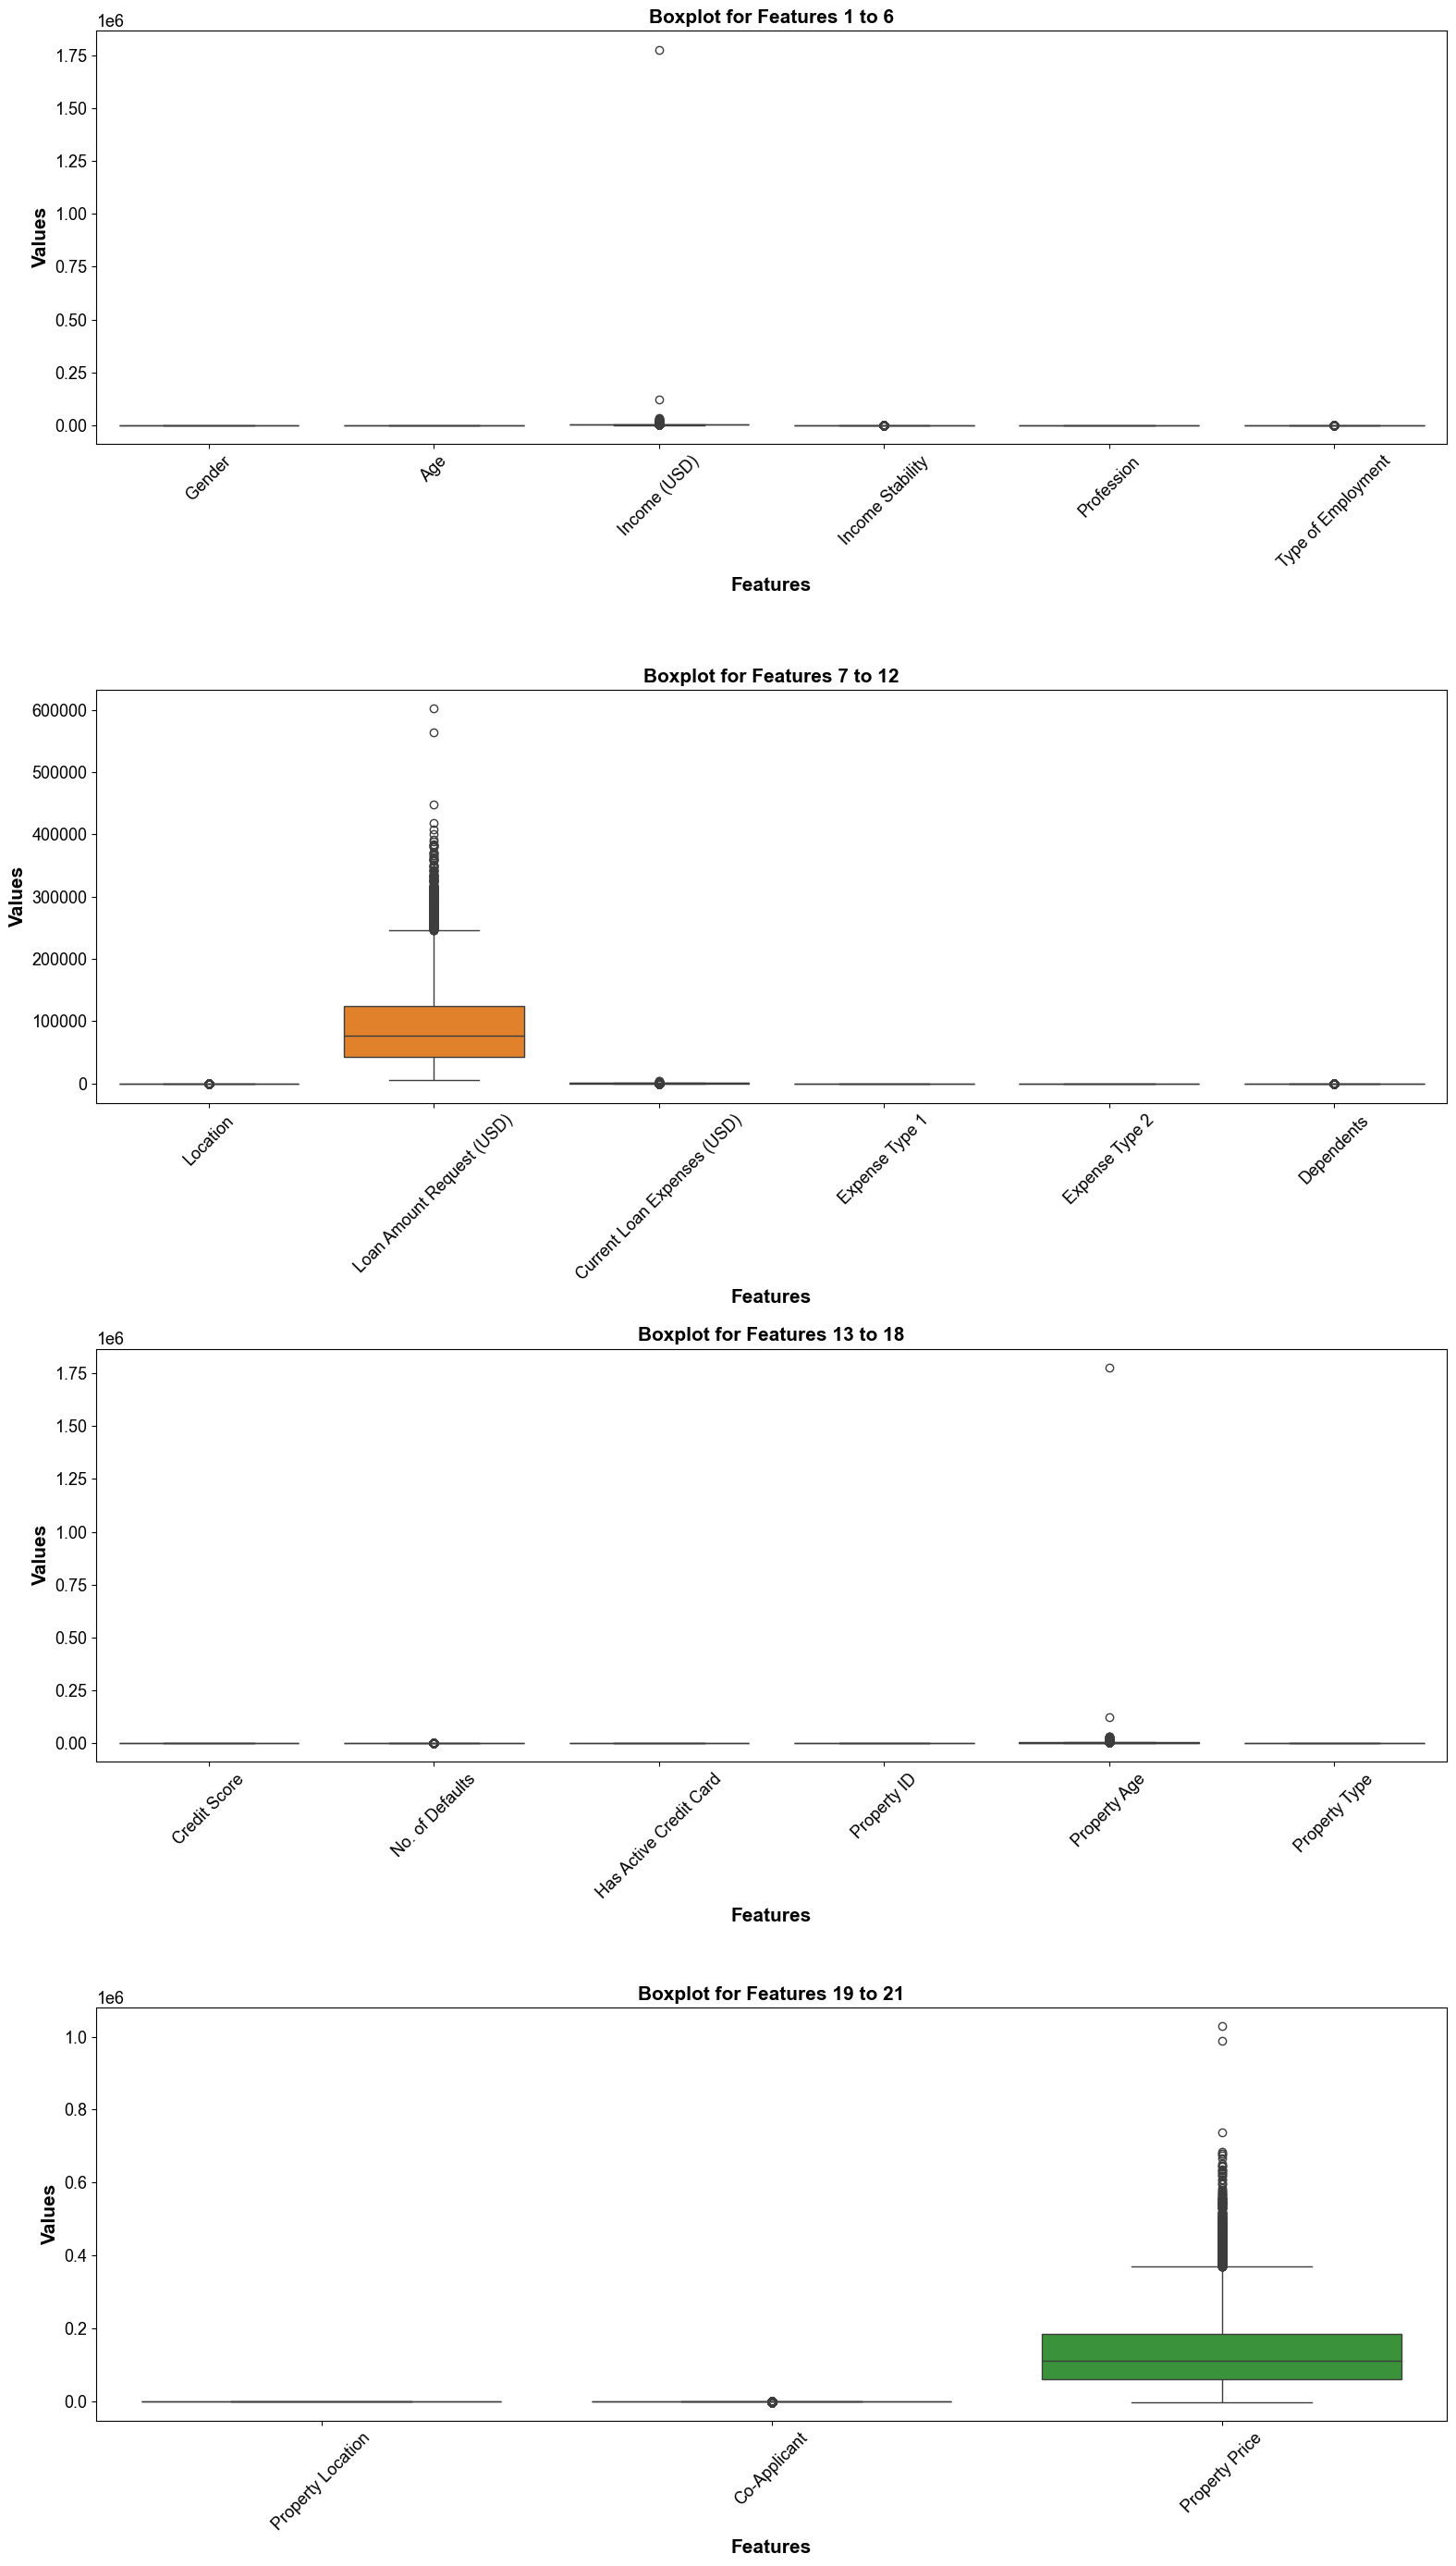

In [38]:
# Boxplot for outliers.

cols_per_plot = 6  # number of features in each subplot
total_cols = X.shape[1]
num_plots = math.ceil(total_cols / cols_per_plot)

fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(16, num_plots*7))

for i in range(num_plots):
    start_col = i * cols_per_plot
    end_col = min((i+1) * cols_per_plot, total_cols)
    subset = X.iloc[:, start_col:end_col]  # select subset of columns
    
    sns.boxplot(data=subset, ax=axes[i])
    axes[i].set_title(f"Boxplot for Features {start_col+1} to {end_col}")
    axes[i].set_xlabel("Features")
    axes[i].set_ylabel("Values")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()




In [39]:
# Handling outliers by using capping.

upper_limit = df_train['Loan Sanction Amount (USD)'].quantile(0.95)
lower_limit = df_train['Loan Sanction Amount (USD)'].quantile(0.05)
df_train['Loan Sanction Amount (USD)'] = np.where(df_train['Loan Sanction Amount (USD)']>upper_limit, upper_limit,
                                            np.where(df_train['Loan Sanction Amount (USD)']<lower_limit, lower_limit, df_train['Loan Sanction Amount (USD)']))


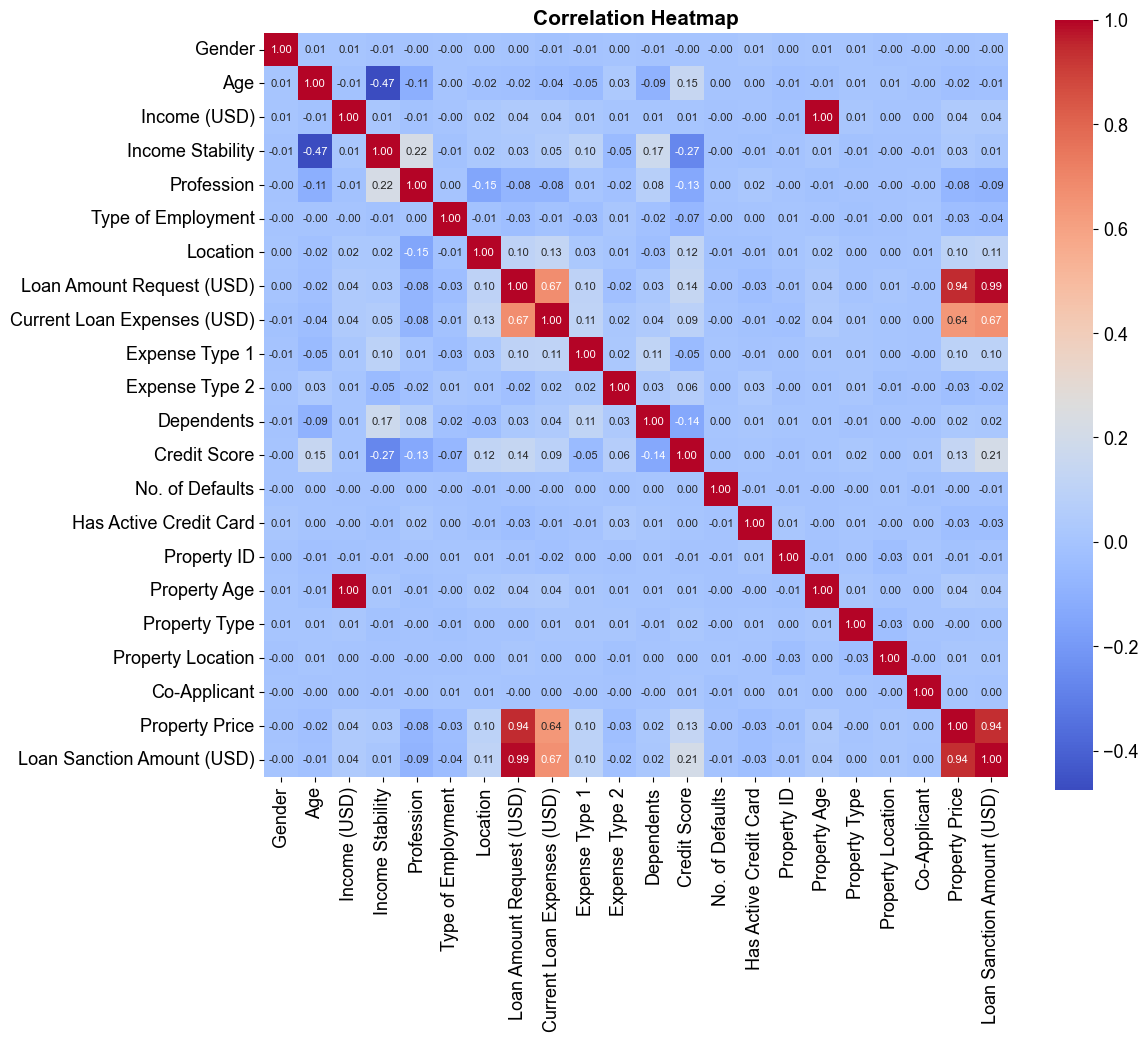

In [40]:
## Heatmap plot for correlation analysis
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    annot_kws={"size": 8}
)
plt.title("Correlation Heatmap")
plt.show()


### 4. Visualize feature distributions and target distribution

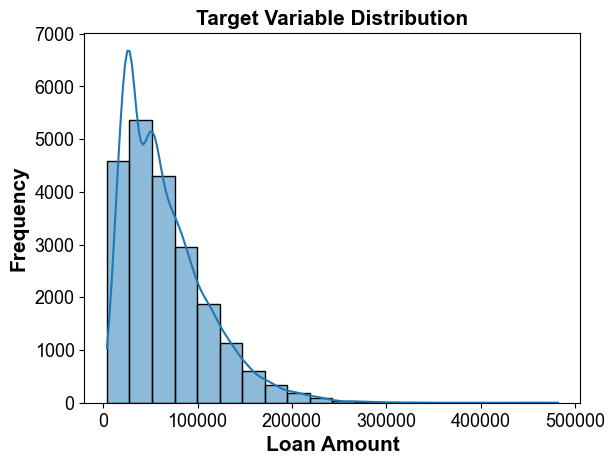

In [41]:
## Target variable distribution plot
plt.figure()
sns.histplot(y, bins=20, kde=True)
plt.title("Target Variable Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()


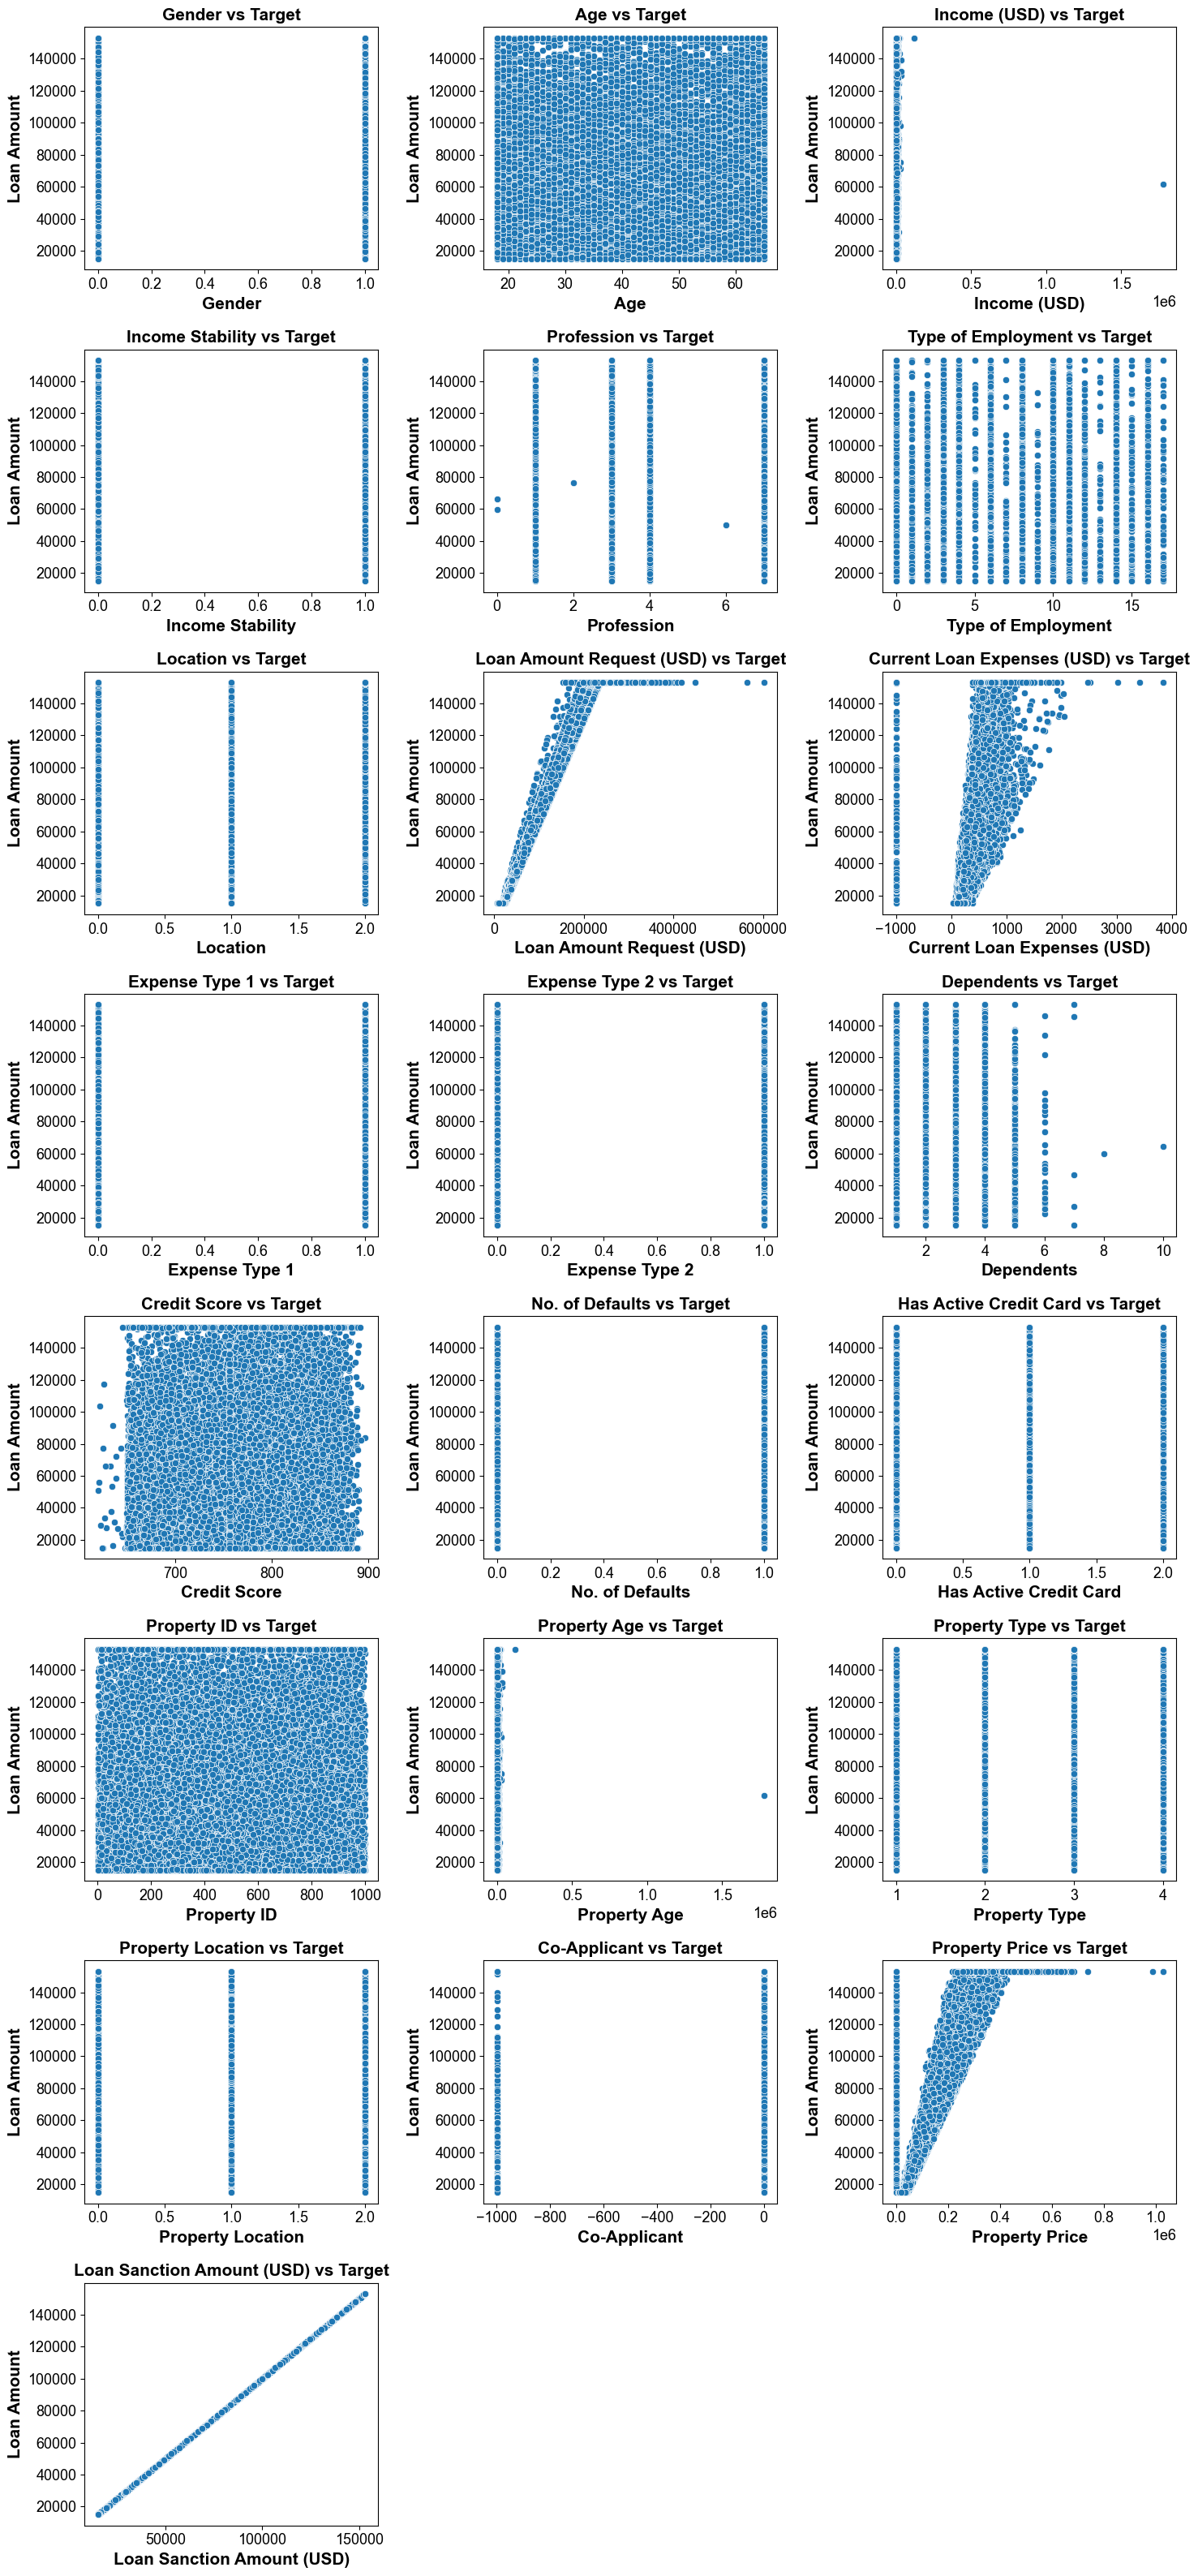

In [42]:
# Feature vs. target scatter plots
# Select numerical features
num_features = df_train.select_dtypes(include=['int64', 'float64']).columns

# Number of columns
cols = 3
rows = math.ceil(len(num_features) / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

# Plot each feature
for i, col in enumerate(num_features):
    sns.scatterplot(x=df_train[col], y=df_train["Loan Sanction Amount (USD)"], ax=axes[i])
    axes[i].set_title(f"{col} vs Target")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Loan Amount")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



### 5. Split the dataset into training and testing sets

In [43]:
## Split the dataset into training and testing sets
X_train, X_val, y_train, y_val = train_test_split( X, y, test_size=0.2, random_state=42)

### 6. Train baseline Linear Regression

In [44]:
# Standardize numerical features
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(df_test)

In [45]:
reg = LinearRegression()

start_time = time.time()               
reg.fit(X_train_scaled, y_train)
end_time = time.time()

linear_train_time = end_time - start_time

In [46]:
reg.coef_

array([-3.35170541e+01,  4.01069351e+01,  6.70198456e+01,  6.12348809e+02,
       -1.39400257e+02, -2.71152479e+01,  1.25388172e+02,  5.84918739e+04,
       -1.23479149e+02, -8.72601978e+01,  7.22321129e+01, -7.56460325e+01,
        4.84069122e+03, -1.07396914e+02, -6.28167736e+01, -8.07352005e-03,
       -1.01794601e+02,  1.69958509e+02,  6.84816204e+01, -9.06607529e-02,
        6.83874557e+02])

In [47]:
reg.intercept_

np.float64(55322.573192074386)

In [48]:
y_val_pred = reg.predict(X_val_scaled)

mae = mean_absolute_error(y_val, y_val_pred)
mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_val_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared (R²) Score:", r2)
print("Training_Time_sec: ", round(linear_train_time, 4))

Mean Absolute Error: 3744.433290634266
Mean Squared Error: 31183449.413339946
R-squared (R²) Score: 0.985153985369452
Training_Time_sec:  0.0265


In [ ]:
# Prediction for the test data and storing the predictions as csv file.
test_predictions = reg.predict(X_test_scaled)

submission = pd.DataFrame({
    "Loan Sanction Amount (USD)": test_predictions
})

submission.to_csv("datasets/submission.csv", index=False)


### 7. Train Ridge, Lasso, and Elastic Net models

#### Ridge Regression

In [50]:
ridge_model = Ridge(alpha=1.0)  # default regularization

start_time = time.time()               
ridge_model.fit(X_train_scaled, y_train)
end_time = time.time()
ridge_train_time = end_time - start_time

In [51]:
y_val_pred_ridge = ridge_model.predict(X_val_scaled)

In [52]:
ridge_mae = mean_absolute_error(y_val, y_val_pred_ridge)
ridge_mse = mean_squared_error(y_val, y_val_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_val, y_val_pred_ridge)

print("Ridge Regression Performance:")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)
print("Training_Time_sec: ", round(ridge_train_time, 4))

Ridge Regression Performance:
MAE : 3744.393204456428
RMSE: 5583.6548557227925
R²  : 0.9851569598929385
Training_Time_sec:  0.013


#### Lasso Regression

In [53]:
lasso_model = Lasso(alpha=0.01, max_iter=10000)

start_time = time.time()               
lasso_model.fit(X_train_scaled, y_train)
end_time = time.time()
lasso_train_time = end_time - start_time

In [54]:
y_val_pred_lasso = lasso_model.predict(X_val_scaled)


In [55]:
lasso_mae = mean_absolute_error(y_val, y_val_pred_lasso)
lasso_mse = mean_squared_error(y_val, y_val_pred_lasso)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_val, y_val_pred_lasso)

print("Lasso Regression Performance:")
print("MAE :", lasso_mae)
print("RMSE:", lasso_rmse)
print("R²  :", lasso_r2)
print("Training_Time_sec: ", round(lasso_train_time, 4))

Lasso Regression Performance:
MAE : 3744.424001203047
RMSE: 5584.186495442789
R²  : 0.9851541332406606
Training_Time_sec:  8.631


#### Elastic Net Regression

In [ ]:
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)

start_time = time.time()               
elastic_model.fit(X_train_scaled, y_train)
end_time = time.time()
elastic_train_time = end_time - start_time

In [57]:
y_val_pred_elastic = elastic_model.predict(X_val_scaled)

In [58]:
elastic_mae = mean_absolute_error(y_val, y_val_pred_elastic)
elastic_mse = mean_squared_error(y_val, y_val_pred_elastic)
elastic_rmse = np.sqrt(elastic_mse)
elastic_r2 = r2_score(y_val, y_val_pred_elastic)

print("Elastic Net Regression Performance:")
print("MAE :", elastic_mae)
print("RMSE:", elastic_rmse)
print("R²  :", elastic_r2)
print("Training_Time_sec: ", round(elastic_train_time, 4))

Elastic Net Regression Performance:
MAE : 5079.36787755241
RMSE: 8421.376142240082
R²  : 0.9662361578140766
Training_Time_sec:  1.3807


### 8. Perform hyperparameter tuning using 5-Fold Cross-Validation

#### Hyperparameter Tuning for Ridge Regression

##### Grid Search CV

In [59]:
ridge = Ridge()

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_train_scaled, y_train)
print("Best Ridge Parameters:", ridge_grid.best_params_)
print("Best Ridge CV R2 Score:", ridge_grid.best_score_)


Best Ridge Parameters: {'alpha': 0.1}
Best Ridge CV R2 Score: 0.9861231093381375


#### Hyperparameter Tuning for Lasso Regression

In [67]:
lasso = Lasso(max_iter=50000)

lasso_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    lasso,
    lasso_params,
    cv=5,
    scoring="r2"
)

lasso_grid.fit(X_train_scaled, y_train)

print("Best Lasso Parameters:", lasso_grid.best_params_)
print("Best Lasso CV R2 Score:", lasso_grid.best_score_)


Best Lasso Parameters: {'alpha': 10}
Best Lasso CV R2 Score: 0.9861299708855557


#### Hyperparameter Tuning for Elastic Net Regression

In [68]:
# Grid Search CV
elastic = ElasticNet(max_iter=50000)

elastic_params = {
    "alpha": [0.01, 0.1, 1, 10],
    "l1_ratio": [0.2, 0.5, 0.8]
}

elastic_grid = GridSearchCV(
    elastic,
    elastic_params,
    cv=5,
    scoring="r2"
)

elastic_grid.fit(X_train_scaled, y_train)

print("Best Elastic Net Parameters:", elastic_grid.best_params_)
print("Best Elastic Net CV R2 Score:", elastic_grid.best_score_)


Best Elastic Net Parameters: {'alpha': 0.01, 'l1_ratio': 0.8}
Best Elastic Net CV R2 Score: 0.9860138903066066


#### Hyperparameter Tuning Summary Table

In [69]:
tuning_summary = pd.DataFrame({
    "Model": ["Ridge Regression", "Lasso Regression", "Elastic Net Regression"],
    "Search Method":["Grid Search CV", "Grid Search CV", "Grid Search CV"],
    "Best Parameters": [
        ridge_grid.best_params_,
        lasso_grid.best_params_,
        elastic_grid.best_params_
    ],
    "Best CV R2": [
        ridge_grid.best_score_,
        lasso_grid.best_score_,
        elastic_grid.best_score_
    ]
})

tuning_summary


,Model,Search Method,Best Parameters,Best CV R2
0,Ridge Regression,Grid Search CV,{'alpha': 0.1},0.986123
1,Lasso Regression,Grid Search CV,{'alpha': 10},0.986130
2,Elastic Net Regression,Grid Search CV,"{'alpha': 0.01, 'l1_ratio': 0.8}",0.986014


### 9. Evaluate all models using regression metrics

In [70]:
# Get Best Tuned Models

best_ridge = ridge_grid.best_estimator_
best_lasso = lasso_grid.best_estimator_
best_elastic = elastic_grid.best_estimator_


In [71]:
# Predictions on Validation Set

y_val_pred_lr = reg.predict(X_val_scaled)

y_val_pred_ridge = best_ridge.predict(X_val_scaled)
y_val_pred_lasso = best_lasso.predict(X_val_scaled)
y_val_pred_elastic = best_elastic.predict(X_val_scaled)


In [64]:
# Define Evaluation Function
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

In [ ]:
lr_metrics = evaluate_model(y_val, y_val_pred_lr)
ridge_metrics = evaluate_model(y_val, y_val_pred_ridge)
lasso_metrics = evaluate_model(y_val, y_val_pred_lasso)
elastic_metrics = evaluate_model(y_val, y_val_pred_elastic)

In [66]:
performance_table = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression", "Elastic Net"],
    "MAE": [lr_metrics[0], ridge_metrics[0], lasso_metrics[0], elastic_metrics[0]],
    "MSE": [lr_metrics[1], ridge_metrics[1], lasso_metrics[1], elastic_metrics[1]],
    "RMSE": [lr_metrics[2], ridge_metrics[2], lasso_metrics[2], elastic_metrics[2]],
    "R2 Score": [lr_metrics[3], ridge_metrics[3], lasso_metrics[3], elastic_metrics[3]],
    "Training_Time: ":[linear_train_time, ridge_train_time, lasso_train_time, elastic_train_time]
})

performance_table


,Model,MAE,MSE,RMSE,R2 Score,Training_Time:
0,Linear Regression,3744.433291,3.118345e+07,5584.214306,0.985154,0.013936
1,Ridge Regression,3744.427877,3.118280e+07,5584.156525,0.985154,0.007704
2,Lasso Regression,3737.247386,3.084568e+07,5553.888709,0.985315,4.275369
3,Elastic Net,3755.105739,3.120327e+07,5585.988327,0.985145,0.689382


In [67]:
best_model = performance_table.sort_values("R2 Score", ascending=False).iloc[0]
best_model

Model              Lasso Regression
MAE                     3737.247386
MSE                 30845679.787911
RMSE                    5553.888709
R2 Score                   0.985315
Training_Time:             4.275369
Name: 2, dtype: object

#### Predicted vs Actual Values Plot

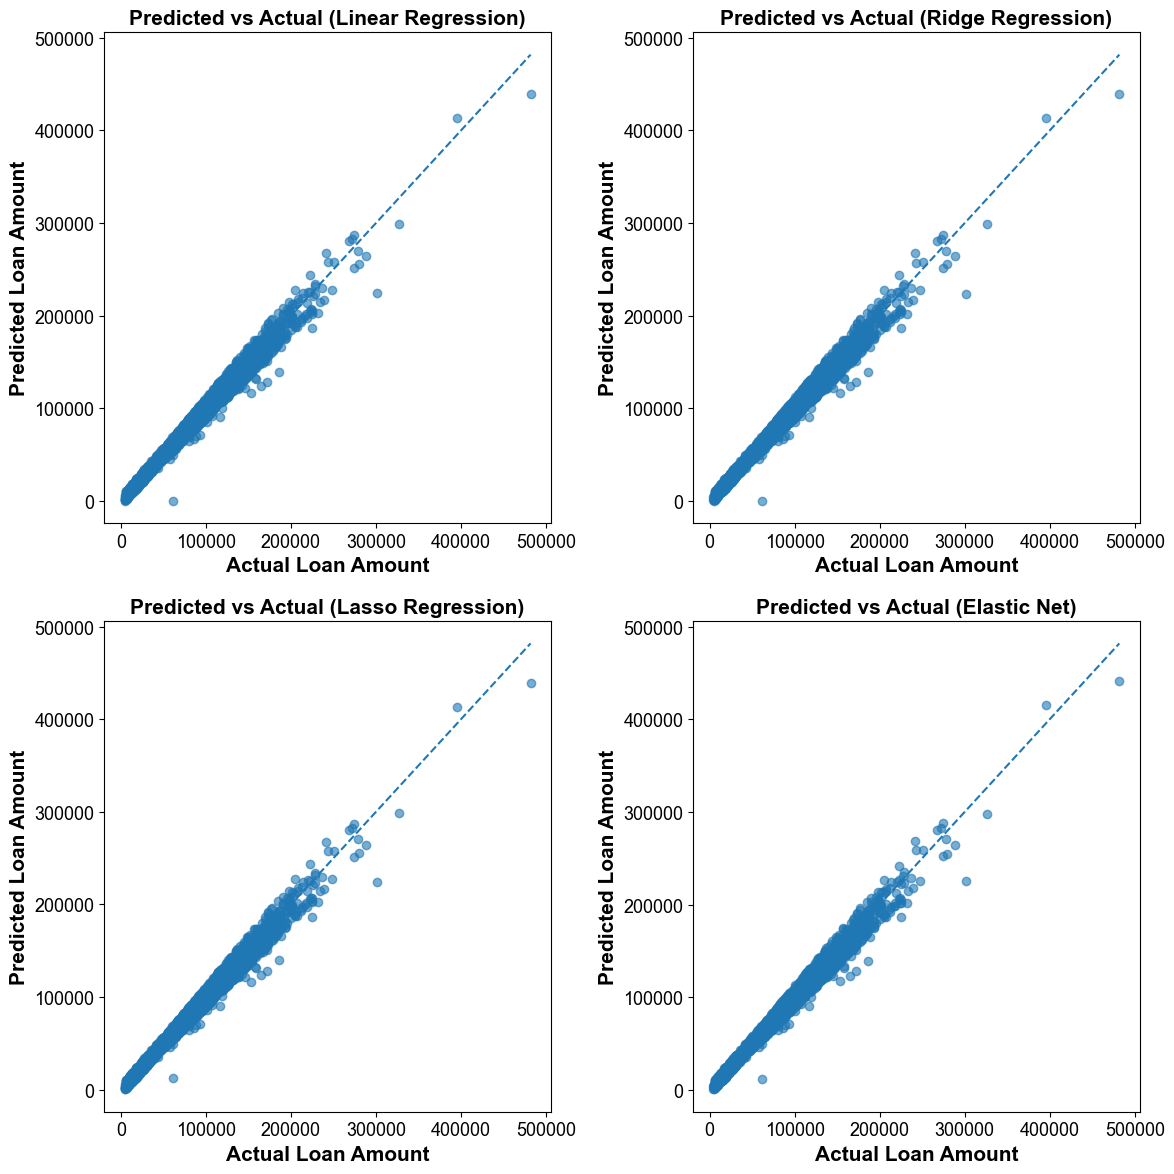

In [73]:
plt.figure(figsize=(12, 12))
models = [
    ("Linear Regression", y_val_pred_lr),
    ("Ridge Regression", y_val_pred_ridge),
    ("Lasso Regression", y_val_pred_lasso),
    ("Elastic Net", y_val_pred_elastic)
]

for i, (title, y_pred) in enumerate(models, 1):
    plt.subplot(2, 2, i)
    
    plt.scatter(y_val, y_pred, alpha=0.6)
    
    plt.plot(
        [y_val.min(), y_val.max()],
        [y_val.min(), y_val.max()],
        linestyle="--"
    )
    
    plt.xlabel("Actual Loan Amount")
    plt.ylabel("Predicted Loan Amount")
    plt.title(f"Predicted vs Actual ({title})")

plt.tight_layout()
plt.show()

#### Residual Plot

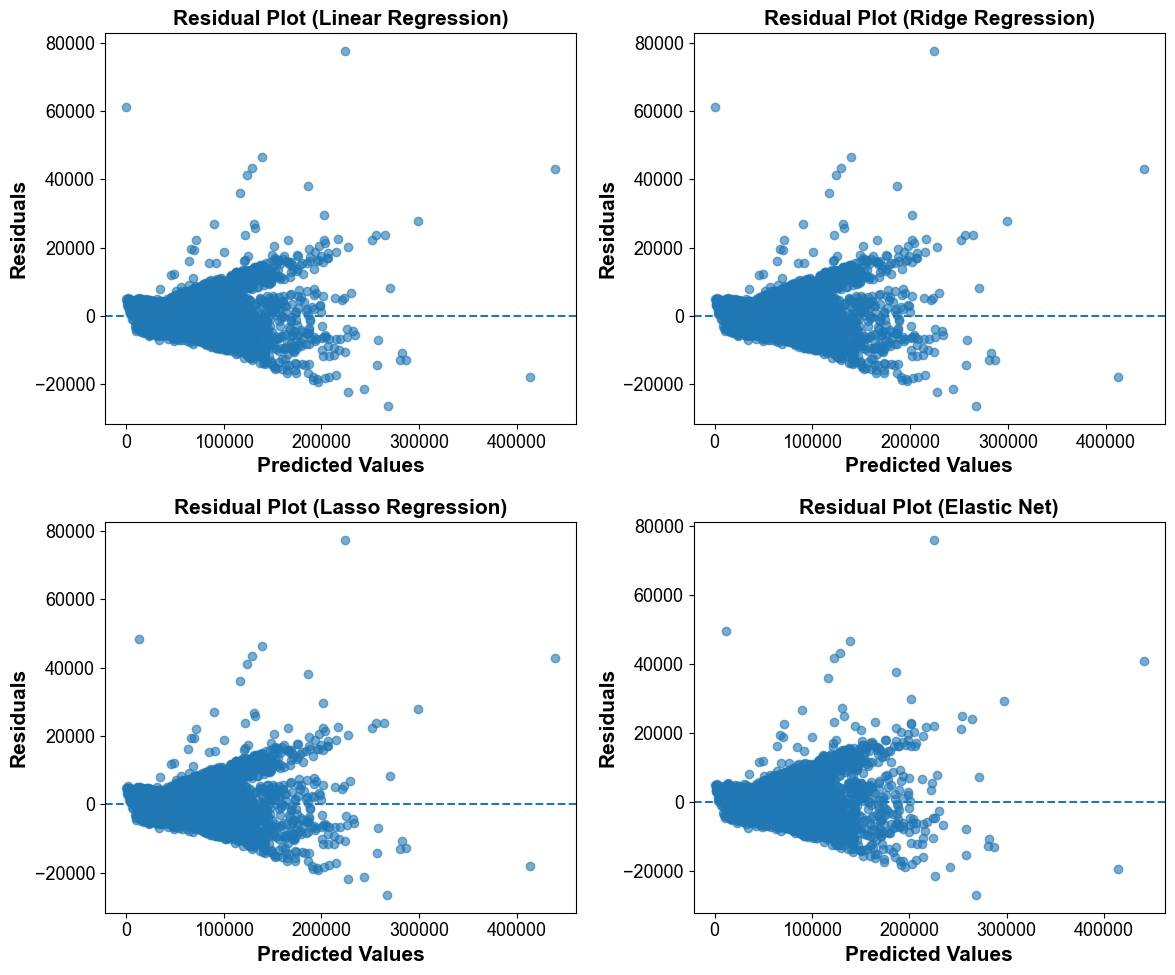

In [74]:
plt.figure(figsize=(12, 10))

for i, (title, y_pred) in enumerate(models, 1):
    residuals = y_val - y_pred
    
    plt.subplot(2, 2, i)
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(0, linestyle="--")
    
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot ({title})")

plt.tight_layout()
plt.show()

#### Training Error vs Validation Error Plot

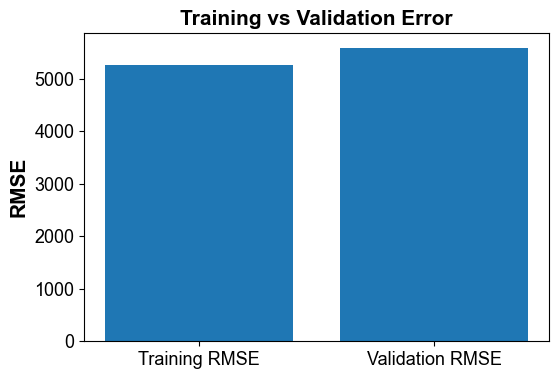

In [75]:
train_pred = best_elastic.predict(X_train_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_elastic))

plt.figure(figsize=(6,4))
plt.bar(["Training RMSE", "Validation RMSE"], [train_rmse, val_rmse])
plt.title("Training vs Validation Error")
plt.ylabel("RMSE")
plt.show()


#### Coefficient Comparison Bar Plot

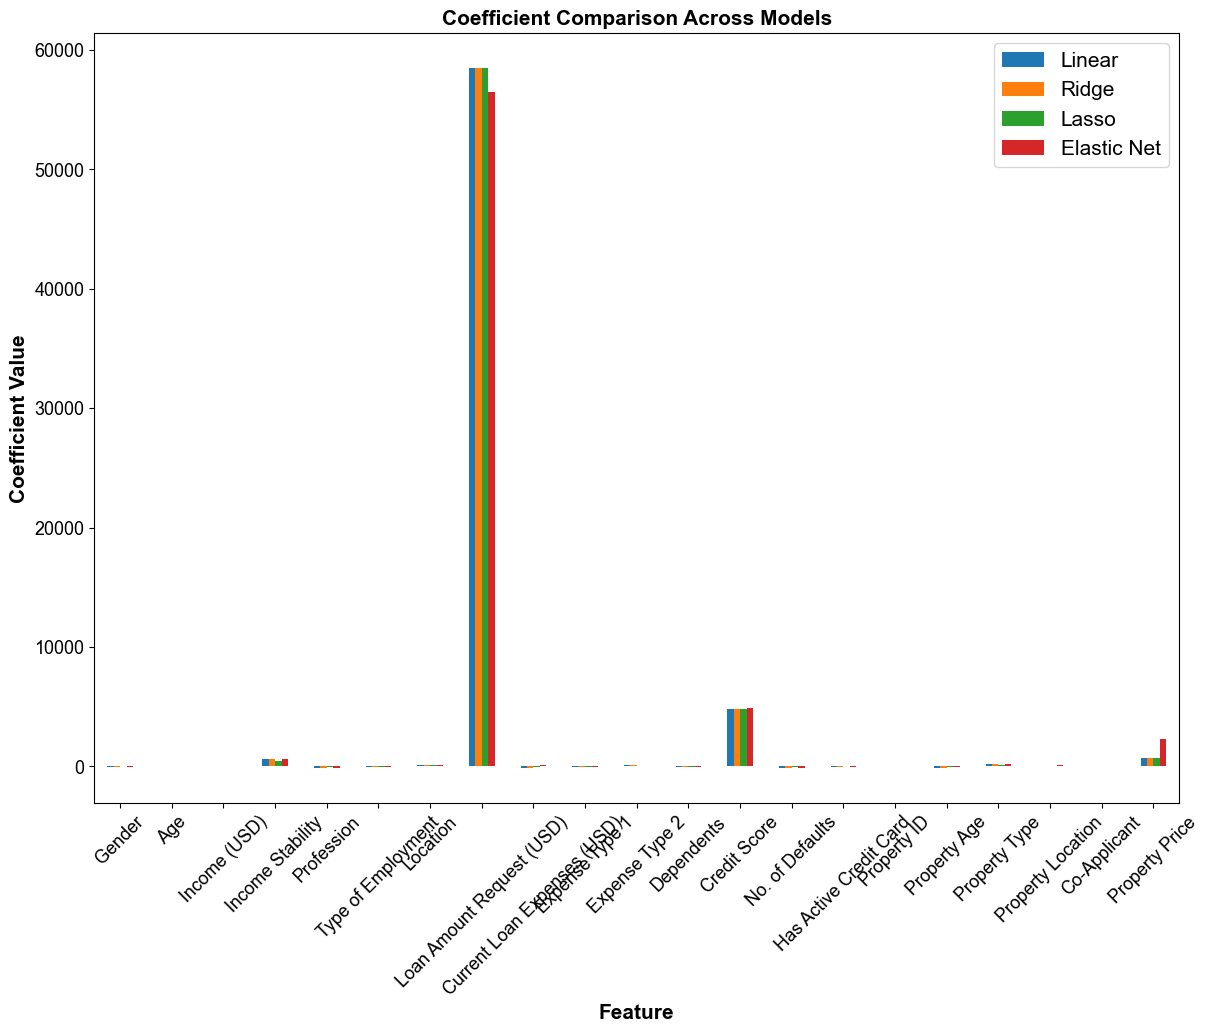

In [77]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Linear": reg.coef_,
    "Ridge": best_ridge.coef_,
    "Lasso": best_lasso.coef_,
    "Elastic Net": best_elastic.coef_
})

coef_df.set_index("Feature").plot(kind="bar", figsize=(14,10))
plt.title("Coefficient Comparison Across Models")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.show()


### Additional Plots.

##### Lambda vs Slope Plot for Ridge & Lasso Regression

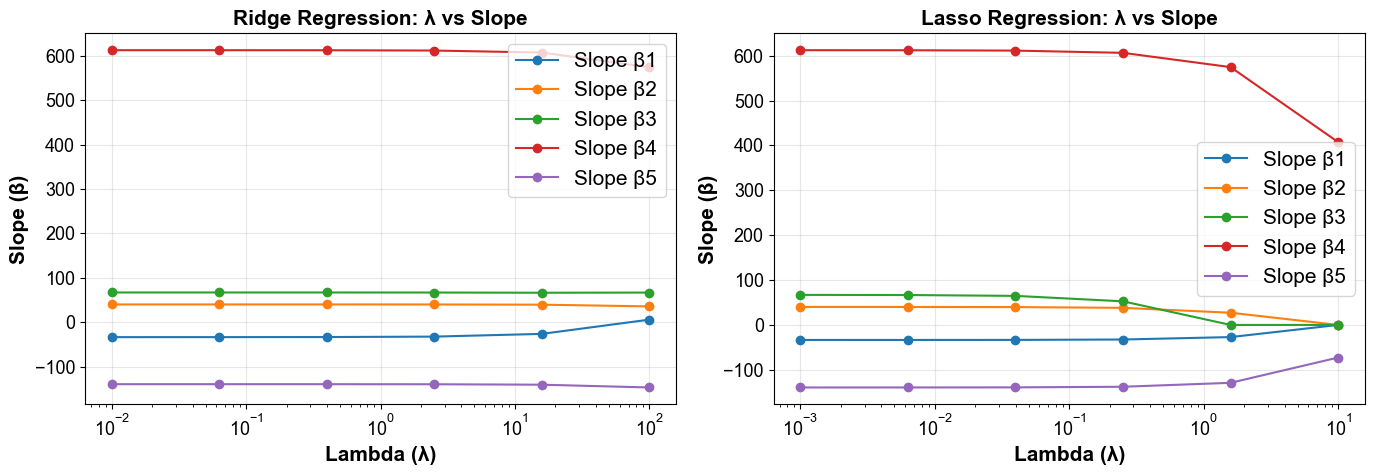

In [78]:
# λ vs Slope (β) for Ridge & Lasso

ridge_lambdas = np.logspace(-2, 2, 6)
lasso_lambdas = np.logspace(-3, 1, 6)

ridge_slopes = []
lasso_slopes = []

for lam in ridge_lambdas:
    model = Ridge(alpha=lam)
    model.fit(X_train_scaled, y_train)
    ridge_slopes.append(model.coef_)

for lam in lasso_lambdas:
    model = Lasso(alpha=lam, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    lasso_slopes.append(model.coef_)

ridge_slopes = np.array(ridge_slopes)
lasso_slopes = np.array(lasso_slopes)

num_features = min(5, ridge_slopes.shape[1])

plt.figure(figsize=(14, 5))

# Ridge
plt.subplot(1, 2, 1)
for i in range(num_features):
    plt.plot(ridge_lambdas, ridge_slopes[:, i], marker='o', label=f'Slope β{i+1}')
plt.xscale('log')
plt.xlabel('Lambda (λ)')
plt.ylabel('Slope (β)')
plt.title('Ridge Regression: λ vs Slope')
plt.legend()
plt.grid(True, alpha=0.3)

# Lasso
plt.subplot(1, 2, 2)
for i in range(num_features):
    plt.plot(lasso_lambdas, lasso_slopes[:, i], marker='o', label=f'Slope β{i+1}')
plt.xscale('log')
plt.xlabel('Lambda (λ)')
plt.ylabel('Slope (β)')
plt.title('Lasso Regression: λ vs Slope')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


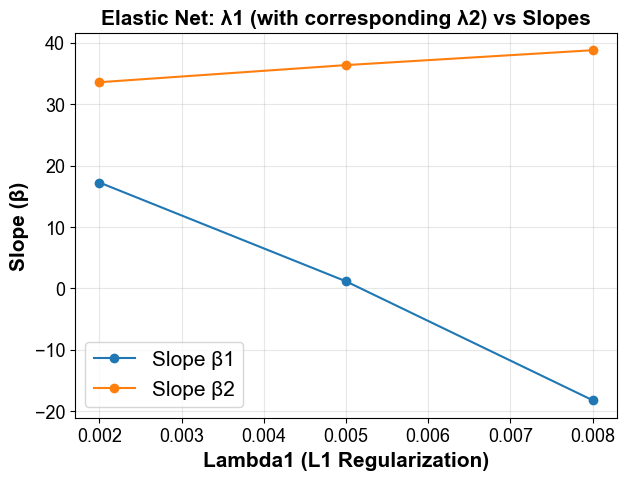

Lambda₁ values: [0.002, 0.005, 0.008]
Lambda₂ values: [0.008, 0.005, 0.0019999999999999996]


In [79]:
# Elastic Net: λ1, λ2 vs Slopes (β)

alpha = best_elastic.alpha          # already obtained from CV
l1_ratios = [0.2, 0.5, 0.8]          # simple, clear values

lambda1_vals = []
lambda2_vals = []
slope1_vals = []
slope2_vals = []

for l1 in l1_ratios:
    lambda1 = alpha * l1
    lambda2 = alpha * (1 - l1)

    model = ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000)
    model.fit(X_train_scaled, y_train)

    lambda1_vals.append(lambda1)
    lambda2_vals.append(lambda2)
    slope1_vals.append(model.coef_[0])   # β1
    slope2_vals.append(model.coef_[1])   # β2

# ---- Plot ----
plt.figure(figsize=(7, 5))

plt.plot(lambda1_vals, slope1_vals, marker='o', label='Slope β1')
plt.plot(lambda1_vals, slope2_vals, marker='o', label='Slope β2')

plt.xlabel('Lambda1 (L1 Regularization)')
plt.ylabel('Slope (β)')
plt.title('Elastic Net: λ1 (with corresponding λ2) vs Slopes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Optional (but good for viva clarity)
print("Lambda₁ values:", lambda1_vals)
print("Lambda₂ values:", lambda2_vals)


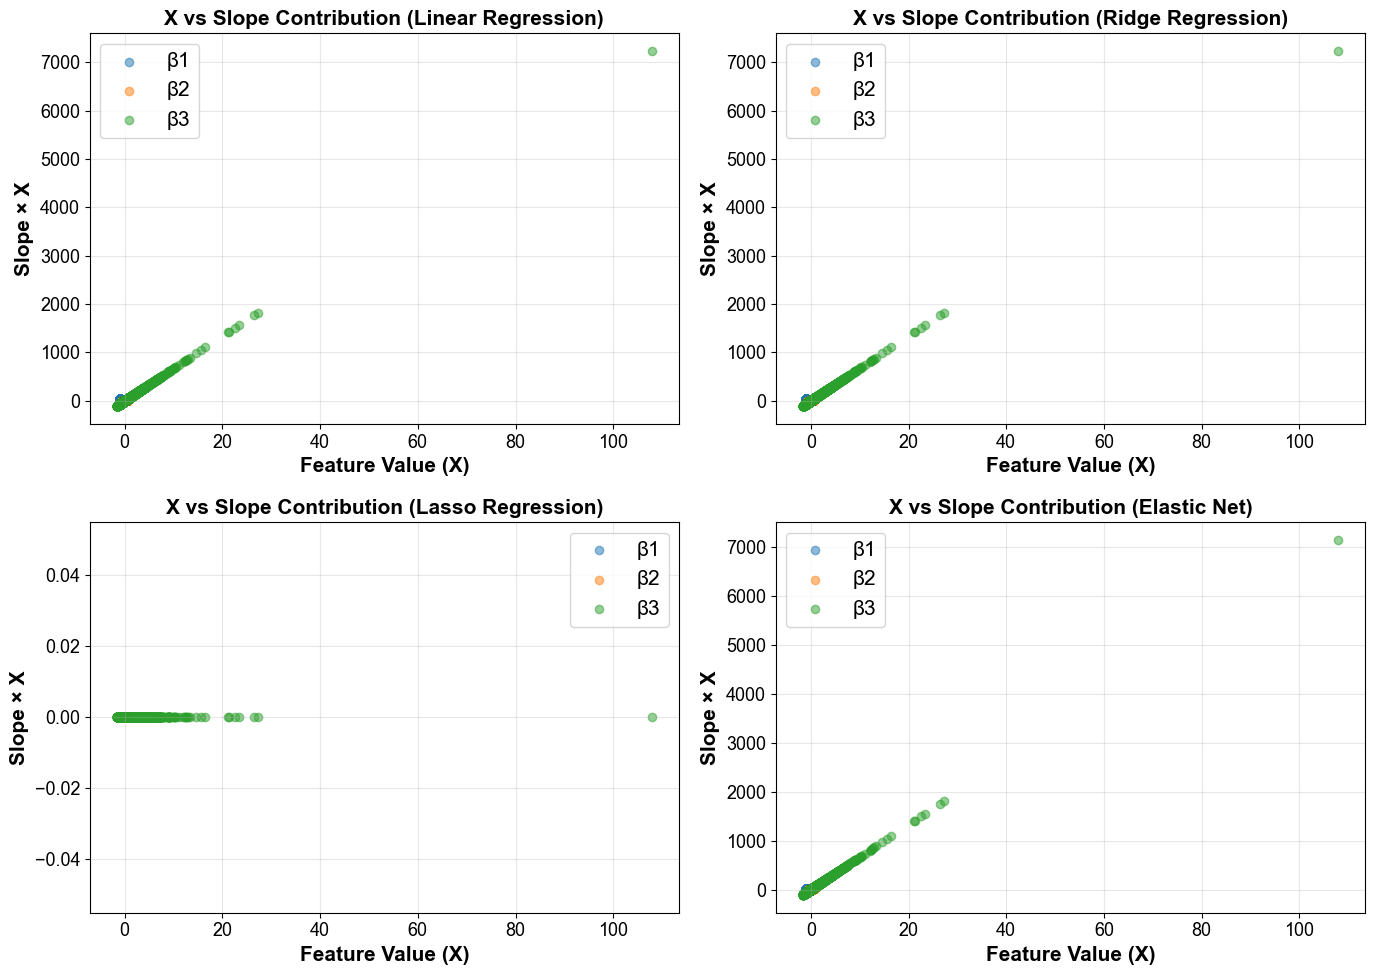

In [ ]:
plt.figure(figsize=(14, 10))
models = [
    ("Linear Regression", reg),
    ("Ridge Regression", best_ridge),
    ("Lasso Regression", best_lasso),
    ("Elastic Net", best_elastic)
]

for idx, (title, model) in enumerate(models, 1):
    plt.subplot(2, 2, idx)
    for i in range(min(3, X_train_scaled.shape[1])):
        contribution = X_train_scaled[:, i] * model.coef_[i]
        plt.scatter(
            X_train_scaled[:, i],
            contribution,
            alpha=0.5,
            label=f'β{i+1}'
        )
    plt.xlabel('Feature Value (X)')
    plt.ylabel('Slope × X')
    plt.title(f'X vs Slope Contribution ({title})')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
